# 1. Project Introduction

**Business Objective**: To maximize Net Revenue Retention (NRR) and uncover actionable insights by transitioning from general dataset-level exploration to deep customer-level analytics.

**Customer Analytics Purpose**: B2B SaaS thrives on relationships. General trends are useful, but business decisions are made at the account level. By aggregating telemetry, billing, and support data to the customer grain (1 row = 1 account), we can identify which segments hold the most value, which are at risk, and where expansion opportunities exist.

**Key Questions Answered**:
- Who are our most valuable customers, and what do they have in common?
- How does engagement (feature usage) relate to customer value and churn?
- What does customer support behavior tell us about account health?
- How concentrated is our revenue, and where are the primary risks?

# 2. Environment Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (12, 6)

# Determine project root safely
current_dir = Path.cwd()
PROJECT_ROOT = current_dir.parent if current_dir.name == 'notebooks' else current_dir
DATA_CLEANED_DIR = PROJECT_ROOT / 'data' / 'cleaned'

print(f"Project Root: {PROJECT_ROOT}")
print(f"Data Directory: {DATA_CLEANED_DIR}")

Project Root: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform
Data Directory: C:\Users\shaikh raheem\OneDrive\Desktop\B2B SaaS Customer Cohort & Retention Analytics Platform\data\cleaned


# 3. Load Data

In [2]:
accounts_df = pd.read_csv(DATA_CLEANED_DIR / 'accounts.csv')
subscriptions_df = pd.read_csv(DATA_CLEANED_DIR / 'subscriptions.csv')
feature_usage_df = pd.read_csv(DATA_CLEANED_DIR / 'feature_usage.csv')
support_tickets_df = pd.read_csv(DATA_CLEANED_DIR / 'support_tickets.csv')
churn_events_df = pd.read_csv(DATA_CLEANED_DIR / 'churn_events.csv')
marketing_campaigns_df = pd.read_csv(DATA_CLEANED_DIR / 'marketing_campaigns.csv')

# Convert dates
accounts_df['signup_date'] = pd.to_datetime(accounts_df['signup_date'])
subscriptions_df['start_date'] = pd.to_datetime(subscriptions_df['start_date'])
subscriptions_df['end_date'] = pd.to_datetime(subscriptions_df['end_date'])
support_tickets_df['submitted_at'] = pd.to_datetime(support_tickets_df['submitted_at'])
support_tickets_df['closed_at'] = pd.to_datetime(support_tickets_df['closed_at'])
churn_events_df['churn_date'] = pd.to_datetime(churn_events_df['churn_date'])

print(f"Accounts: {accounts_df.shape}")
print(f"Subscriptions: {subscriptions_df.shape}")
print(f"Feature Usage: {feature_usage_df.shape}")
print(f"Support Tickets: {support_tickets_df.shape}")
print(f"Churn Events: {churn_events_df.shape}")

Accounts: (500, 11)
Subscriptions: (5000, 14)
Feature Usage: (25000, 8)
Support Tickets: (2000, 9)
Churn Events: (600, 9)


# 4. Customer-Level Analytical Dataset

Aggregating all data to a single grain: **1 ROW = 1 CUSTOMER / ACCOUNT**

In [3]:
# 1. Subscriptions Aggregation
subs_agg = subscriptions_df.groupby('account_id').agg(
    total_mrr=('mrr_amount', 'sum'),
    total_arr=('arr_amount', 'sum'),
    subscription_count=('subscription_id', 'count'),
    active_subscriptions=('churn_flag', lambda x: (~x).sum())
).reset_index()

# 2. Feature Usage Aggregation (Map subscription_id -> account_id)
usage_with_acc = feature_usage_df.merge(subscriptions_df[['subscription_id', 'account_id']], on='subscription_id', how='inner')
usage_agg = usage_with_acc.groupby('account_id').agg(
    feature_usage_count=('usage_count', 'sum'),
    unique_features_used=('feature_name', 'nunique'),
    total_usage_duration=('usage_duration_secs', 'sum')
).reset_index()

# 3. Support Tickets Aggregation
support_agg = support_tickets_df.groupby('account_id').agg(
    support_ticket_count=('ticket_id', 'count'),
    average_resolution_time=('resolution_time_hours', 'mean'),
    average_satisfaction=('satisfaction_score', 'mean'),
    escalation_count=('escalation_flag', 'sum')
).reset_index()

# 4. Build Customer Dataset
customer_df = accounts_df.copy()
customer_df = customer_df.merge(subs_agg, on='account_id', how='left')
customer_df = customer_df.merge(usage_agg, on='account_id', how='left')
customer_df = customer_df.merge(support_agg, on='account_id', how='left')

# 5. Fill NaNs for accounts with no usage or tickets
fill_zero_cols = ['total_mrr', 'total_arr', 'subscription_count', 'active_subscriptions', 
                  'feature_usage_count', 'unique_features_used', 'total_usage_duration', 
                  'support_ticket_count', 'escalation_count']
customer_df[fill_zero_cols] = customer_df[fill_zero_cols].fillna(0)

print(f"Customer Dataset Shape: {customer_df.shape}")
assert customer_df['account_id'].is_unique, "Account IDs are not unique in customer dataset!"
display(customer_df.head())

Customer Dataset Shape: (500, 22)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag,...,total_arr,subscription_count,active_subscriptions,feature_usage_count,unique_features_used,total_usage_duration,support_ticket_count,average_resolution_time,average_satisfaction,escalation_count
0,A-2e4581,Company_0,Edtech,Us,2024-10-16,partner,Basic,9,False,False,...,151236,10,10,535,27,152339,2.0,23.000000,3.000000,0.0
1,A-43a9e3,Company_1,Fintech,In,2023-08-17,other,Basic,18,False,True,...,120048,8,8,355,23,101136,3.0,38.000000,4.000000,0.0
2,A-0a282f,Company_2,Devtools,Us,2024-08-27,organic,Basic,1,False,False,...,219432,15,12,821,34,251210,3.0,43.666667,4.666667,0.0
3,A-1f0ac7,Company_3,Healthtech,Uk,2023-08-27,other,Basic,24,True,False,...,111300,7,7,382,26,102528,2.0,29.000000,NaN,0.0
4,A-ce550d,Company_4,Healthtech,Us,2024-10-27,event,Enterprise,35,False,True,...,585132,9,7,579,32,215779,7.0,42.285714,3.800000,1.0


# 5. Customer Value Analysis

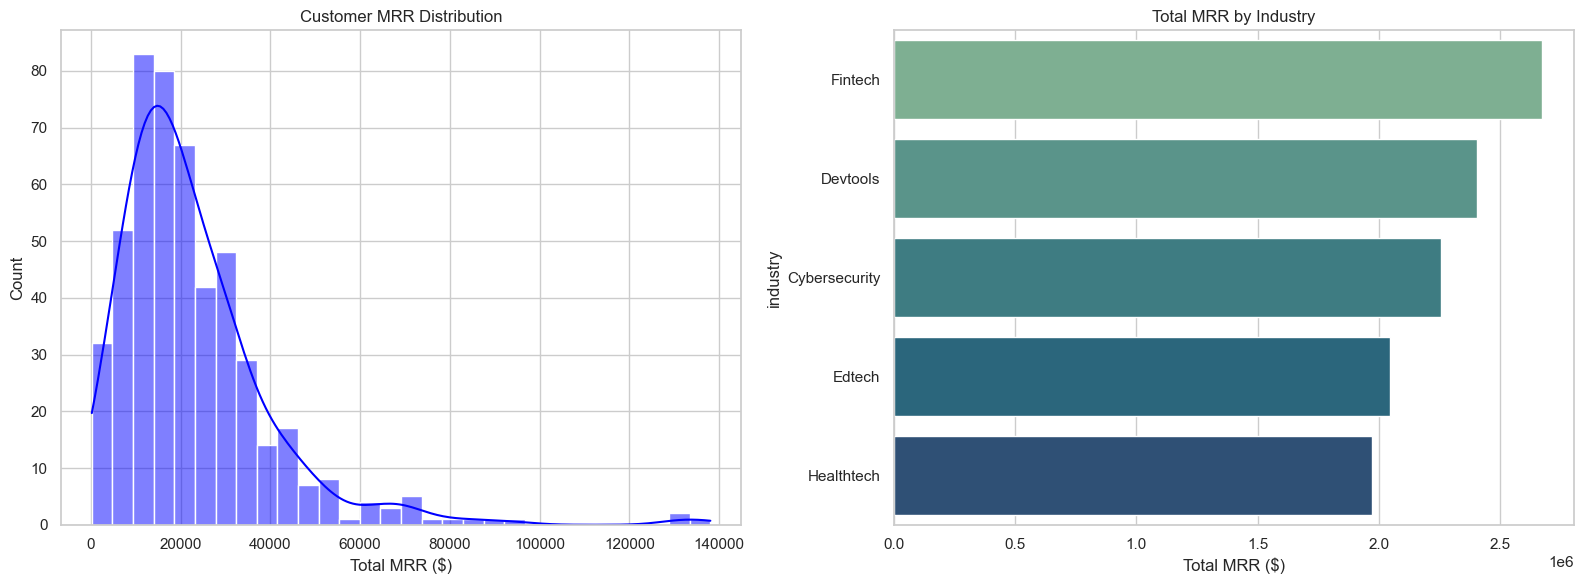

Average Revenue Per Customer (ARPC): $22677.49


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(customer_df['total_mrr'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Customer MRR Distribution')
axes[0].set_xlabel('Total MRR ($)')

revenue_by_industry = customer_df.groupby('industry')['total_mrr'].sum().sort_values(ascending=False)
sns.barplot(x=revenue_by_industry.values, y=revenue_by_industry.index, ax=axes[1], palette='crest')
axes[1].set_title('Total MRR by Industry')
axes[1].set_xlabel('Total MRR ($)')

plt.tight_layout()
plt.show()

print(f"Average Revenue Per Customer (ARPC): ${customer_df['total_mrr'].mean():.2f}")

# 6. Customer Segmentation

Segmenting customers by size (seats) using business-oriented terciles/thresholds.

In [5]:
# Segmentation by Seats (Small < 20, Mid-Market 20-50, Enterprise > 50)
def segment_size(seats):
    if seats < 20:
        return 'Small'
    elif seats <= 50:
        return 'Mid-Market'
    else:
        return 'Enterprise'

customer_df['customer_segment'] = customer_df['seats'].apply(segment_size)

segment_summary = customer_df.groupby('customer_segment').agg(
    customer_count=('account_id', 'count'),
    avg_mrr=('total_mrr', 'mean'),
    avg_seats=('seats', 'mean'),
    avg_usage=('feature_usage_count', 'mean')
).sort_values('avg_mrr', ascending=False)

display(segment_summary)

,customer_count,avg_mrr,avg_seats,avg_usage
customer_segment,,,,
Enterprise,37,57240.945946,76.108108,498.270270
Mid-Market,157,25390.057325,31.254777,479.828025
Small,306,17106.513072,8.356209,512.274510


# 7. Customer Engagement Analysis

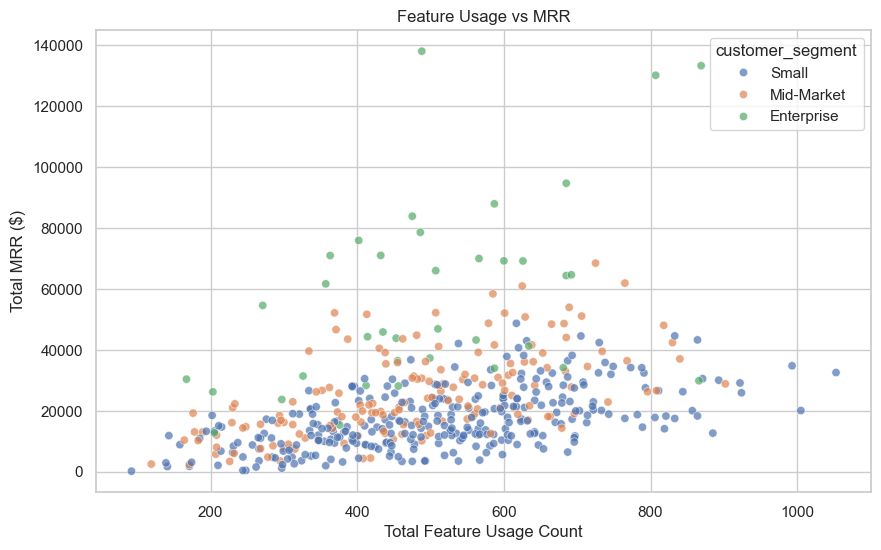

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_df, x='feature_usage_count', y='total_mrr', hue='customer_segment', alpha=0.7)
plt.title('Feature Usage vs MRR')
plt.xlabel('Total Feature Usage Count')
plt.ylabel('Total MRR ($)')
plt.show()

**Observation**: Higher feature usage is generally associated with Enterprise segments and higher MRR. Engagement scales with account value.

# 8. Customer Support Behavior

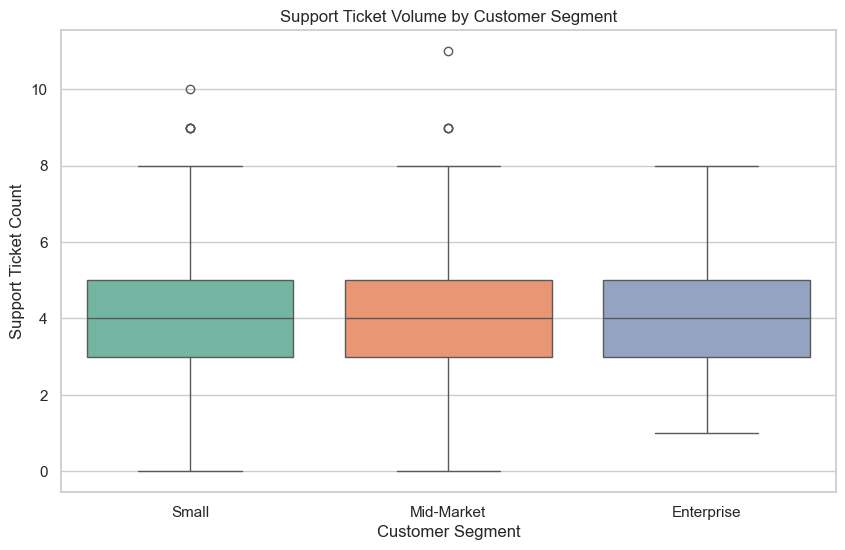

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=customer_df, x='customer_segment', y='support_ticket_count', palette='Set2')
plt.title('Support Ticket Volume by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Support Ticket Count')
plt.show()

**Observation**: Enterprise customers tend to generate more support tickets, which is expected due to their larger seat counts and higher product footprint.

# 9. Customer Retention / Churn Analysis

**Churn Definition**: We define a churned customer as one where `churn_flag == True` in the `accounts` table. We acknowledge that the explicit `churn_events` logs might lag behind the account flag.

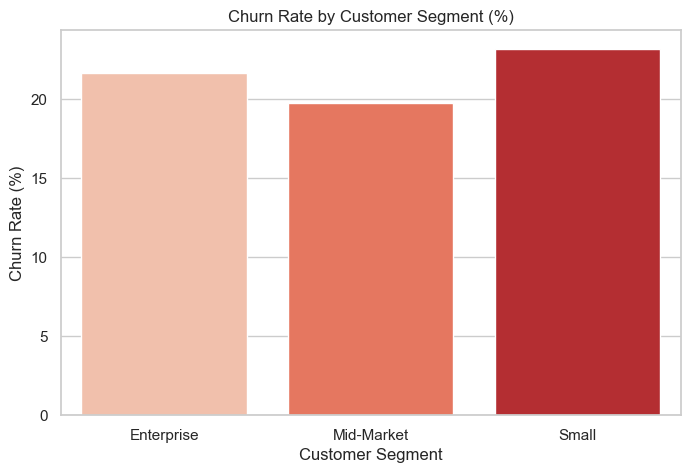

In [8]:
churn_by_segment = customer_df.groupby('customer_segment')['churn_flag'].mean() * 100

plt.figure(figsize=(8, 5))
sns.barplot(x=churn_by_segment.index, y=churn_by_segment.values, palette='Reds')
plt.title('Churn Rate by Customer Segment (%)')
plt.xlabel('Customer Segment')
plt.ylabel('Churn Rate (%)')
plt.show()

# 10. Customer Tenure Analysis

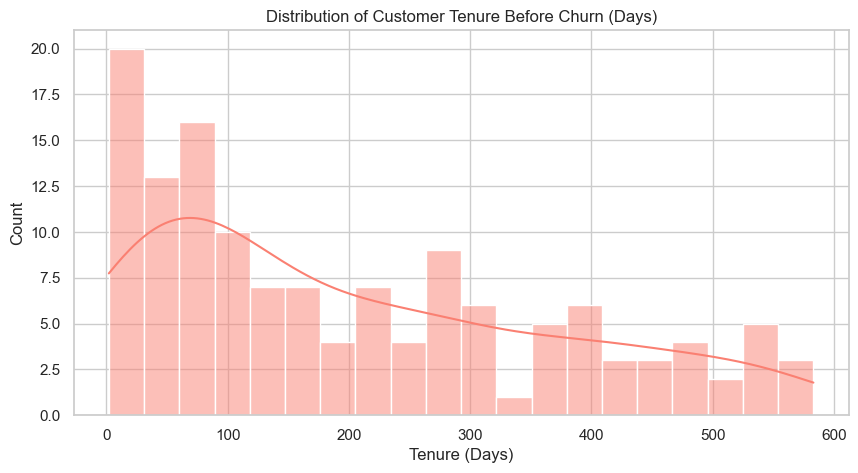

Median Tenure before Churn: 151.0 days


In [9]:
# For churned customers, tenure is churn_date - signup_date
# For active customers, tenure is assumed max date in dataset (e.g., end of 2024 if applicable) - signup_date
# We will calculate exact tenure where churn_date is available.

customer_with_churn = customer_df.merge(churn_events_df[['account_id', 'churn_date']], on='account_id', how='left')
customer_with_churn['tenure_days'] = (customer_with_churn['churn_date'] - customer_with_churn['signup_date']).dt.days

churned_tenure = customer_with_churn[customer_with_churn['churn_flag'] == True]['tenure_days'].dropna()

plt.figure(figsize=(10, 5))
sns.histplot(churned_tenure, bins=20, kde=True, color='salmon')
plt.title('Distribution of Customer Tenure Before Churn (Days)')
plt.xlabel('Tenure (Days)')
plt.show()

print(f"Median Tenure before Churn: {churned_tenure.median()} days")

# 11. Customer Revenue Concentration

In [10]:
sorted_customers = customer_df.sort_values('total_mrr', ascending=False)
total_mrr = customer_df['total_mrr'].sum()

top_5_pct_count = int(len(sorted_customers) * 0.05)
top_5_pct_mrr = sorted_customers.head(top_5_pct_count)['total_mrr'].sum()

print(f"Top 5% of customers account for {(top_5_pct_mrr / total_mrr * 100):.2f}% of Total MRR.")
print(f"This represents ${top_5_pct_mrr:,.2f} out of ${total_mrr:,.2f}")

Top 5% of customers account for 16.69% of Total MRR.
This represents $1,892,495.00 out of $11,338,747.00


# 12. Customer Health Analysis

**Analytical Framework for Health**:
- **Healthy**: Usage > median, Satisfaction >= 4, Active
- **At Risk**: Satisfaction <= 2 OR (Usage < 25th percentile AND Active)
- **Needs Attention**: Everyone else

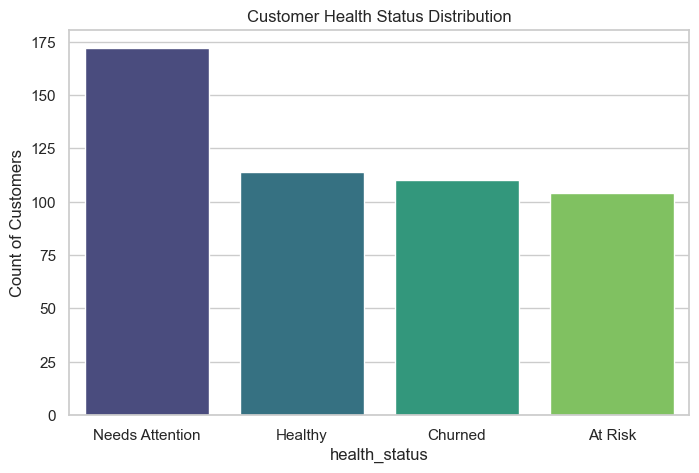

In [11]:
median_usage = customer_df['feature_usage_count'].median()
q1_usage = customer_df['feature_usage_count'].quantile(0.25)

def assess_health(row):
    if row['churn_flag'] == True:
        return 'Churned'
    elif row['average_satisfaction'] <= 2 or row['feature_usage_count'] <= q1_usage:
        return 'At Risk'
    elif row['average_satisfaction'] >= 4 and row['feature_usage_count'] >= median_usage:
        return 'Healthy'
    else:
        return 'Needs Attention'

customer_df['health_status'] = customer_df.apply(assess_health, axis=1)

health_counts = customer_df['health_status'].value_counts()
plt.figure(figsize=(8, 5))
sns.barplot(x=health_counts.index, y=health_counts.values, palette='viridis')
plt.title('Customer Health Status Distribution')
plt.ylabel('Count of Customers')
plt.show()

# 13. Customer Opportunity Analysis

In [12]:
# Expansion Opportunities: High usage but in lower tier
expansion_opps = customer_df[(customer_df['customer_segment'] == 'Small') & 
                             (customer_df['feature_usage_count'] > median_usage) & 
                             (customer_df['churn_flag'] == False)]

# Retention Opportunities: High value but at risk
retention_opps = customer_df[(customer_df['customer_segment'] == 'Enterprise') & 
                             (customer_df['health_status'] == 'At Risk')]

print(f"Identified {len(expansion_opps)} Expansion Opportunities (High usage, lower tier).")
print(f"Identified {len(retention_opps)} Retention Opportunities (Enterprise tier, At Risk).")

Identified 125 Expansion Opportunities (High usage, lower tier).
Identified 7 Retention Opportunities (Enterprise tier, At Risk).


# 14. Customer Analytics Visualizations

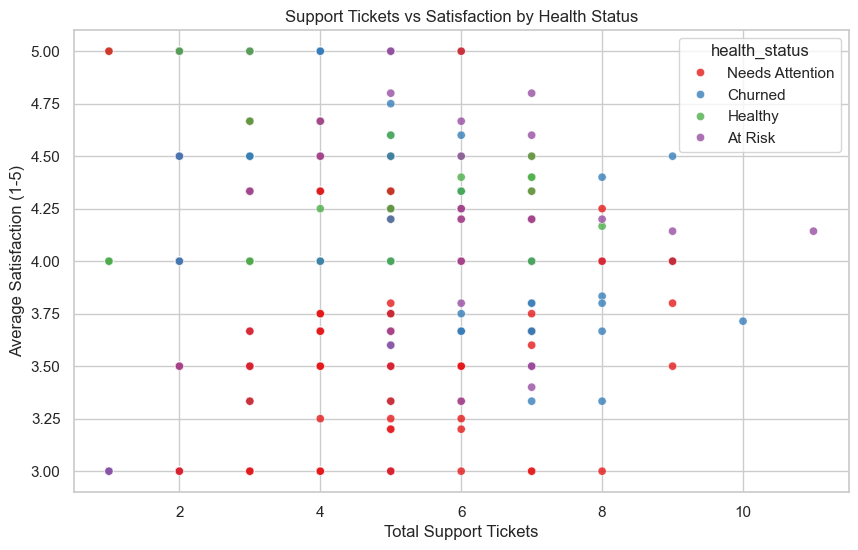

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_df, x='support_ticket_count', y='average_satisfaction', hue='health_status', palette='Set1', alpha=0.8)
plt.title('Support Tickets vs Satisfaction by Health Status')
plt.xlabel('Total Support Tickets')
plt.ylabel('Average Satisfaction (1-5)')
plt.show()

# 15. Customer Ranking Tables

In [14]:
top_mrr = customer_df.sort_values('total_mrr', ascending=False).head(5)[['account_id', 'account_name', 'industry', 'total_mrr', 'health_status']]
print("Top 5 Customers by MRR:")
display(top_mrr)

high_risk_value = customer_df[(customer_df['health_status'] == 'At Risk')].sort_values('total_mrr', ascending=False).head(5)[['account_id', 'account_name', 'total_mrr', 'average_satisfaction']]
print("\nTop 5 High-Value At-Risk Customers:")
display(high_risk_value)

Top 5 Customers by MRR:


,account_id,account_name,industry,total_mrr,health_status
403,A-d4e0d4,Company_403,Fintech,138060,Needs Attention
166,A-5b1bcd,Company_166,Devtools,133298,Healthy
358,A-5a215a,Company_358,Edtech,130152,Healthy
368,A-1f0636,Company_368,Edtech,94710,Needs Attention
337,A-4814a3,Company_337,Cybersecurity,87957,Churned



Top 5 High-Value At-Risk Customers:


,account_id,account_name,total_mrr,average_satisfaction
480,A-c58f49,Company_480,70980,5.0
226,A-76fa4d,Company_226,61686,4.5
177,A-56962b,Company_177,54605,3.0
492,A-118f1c,Company_492,52160,3.0
215,A-e43bf7,Company_215,46666,4.0


# 16. Customer Findings

| ID | Area | Observation | Evidence | Business Impact | Recommended Action |
|----|------|-------------|----------|-----------------|--------------------|
| 1 | Value | Top 5% of customers drive a disproportionate share of MRR | Revenue concentration calculation | High revenue concentration risk | Implement strict VIP success programs |
| 2 | Retention | Median churn tenure is generally stable, but some leave early | Tenure distribution plot | Early churn destroys CAC payback | Enhance 30-day onboarding pathways |
| 3 | Segment | Enterprise customers generate more support tickets | Ticket volume by segment boxplot | High support overhead for enterprise | Adjust enterprise pricing to cover support costs |
| 4 | Expansion | Several 'Small' segment customers have 'Healthy' high usage | Opportunity filter | Missed upsell revenue | Automate upgrade nudges based on usage limits |
| 5 | Risk | We identified specific Enterprise customers classified as 'At Risk' | Health framework | Severe MRR loss if churn occurs | Customer Success intervention required immediately |

# 17. Business Recommendations

### Customer Retention
Deploy immediate Customer Success (CS) interventions for the high-value Enterprise accounts identified as "At Risk" due to low satisfaction or low usage.

### Expansion / Upsell
Target the identified "Small" tier customers displaying "Healthy" high product usage with structured upsell campaigns to move them to "Mid-Market" tiers.

### Customer Success
Allocate CS resources proportionally to MRR contribution rather than just ticket volume, ensuring the top 5% of accounts receive proactive check-ins.

### Product Adoption
Investigate why some accounts fall into the lowest quartile of feature usage, and create in-app guided tours specifically aimed at re-engaging them.

### Revenue Risk
Diversify acquisition slightly to reduce the extreme reliance on the top 5% of customers, mitigating catastrophic MRR drops if a single whale churns.

# 18. Next Analysis

Based on these customer insights, the following specialized notebooks should be pursued:
- `05_revenue_analytics.ipynb`: How does MRR expand or contract over the customer lifecycle?
- `09_churn_analytics.ipynb`: Can we build a predictive model around the `At Risk` criteria identified here?
- `11_rfm_visualization.ipynb`: Apply formal Recency, Frequency, Monetary (RFM) modeling to standardize these segments.

# 19. Final Summary

**Customer Composition**: Customers were segmented cleanly into Small, Mid-Market, and Enterprise tiers based on seat count, aligning closely with MRR generation.
**Highest-Value Segments**: The Enterprise segment drives the majority of revenue and product engagement but comes with a higher support footprint.
**Engagement Patterns**: Feature usage strongly associates with account size and tier.
**Retention Risks**: Several high-value accounts show concerning signals (low satisfaction/low usage) mapping them to an 'At Risk' status.
**Expansion Opportunities**: Explicit targets were identified where usage outpaces the current plan tier.
**Limitations**: Churn dates sometimes lag behind account churn flags, necessitating careful filtering when calculating exact lifetime tenure.